# Optimization Methods

Until now, we've always used Gradient Descent to update the parameters and minimize the cost. In this notebook, we will learn more advanced optimization methods that can speed up learning and perhaps even get we to a better final value for the cost function. Having a good optimization algorithm can be the difference between waiting days vs. just a few hours to get a good result.
Gradient  descent goes "downhill" on a cost function $$J$$. We can think of it as trying to do this:
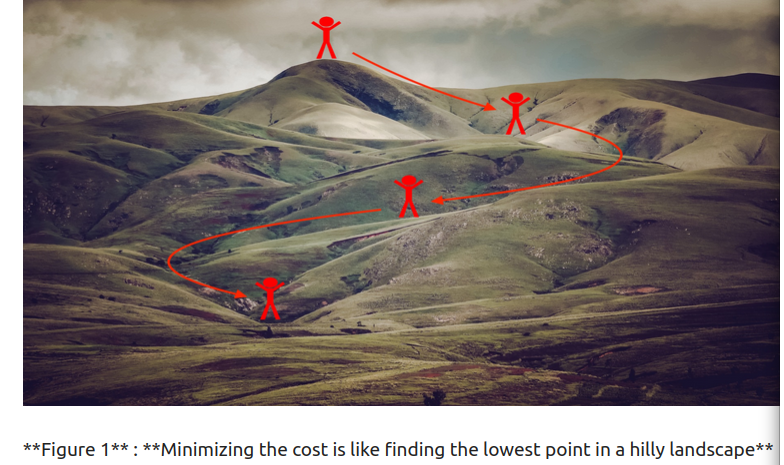


At each step of the training , we update the parameters following a certain direction to get to the lowest possible point.

Note: As usual $$ \frac {dJ}{d_a} $$ = `da` for any variable `a`

Importing all the libraries and dependencies



In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import math
import sklearn
import sklearn.datasets

from opt_utils import load_params_and_grads, initialize_parameters, forward_propagation, backward_propagation
from opt_utils import compute_cost, predict, predict_dec, plot_decision_boundary, load_dataset

from testCases import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


## Gradient Descent

A simple optimization method in machine learning is gradient descent (GD). When you take gradient steps with respect to all $$m$$ examples on each step, it is also called Batch Gradient Descent.

**Warm-up exercise**: Implement te gradient descent update rule:
The grad descent rule is for $$l = 1, ..., L$$

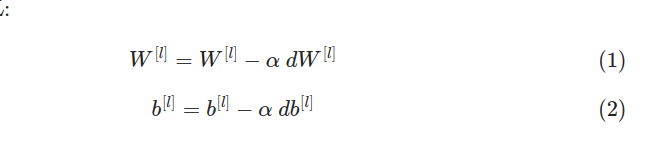

Where L is the number of the layers and $$\alpha$$ is the learning rate. All parameters should stored in the `parameters` dictionary. Note that the iterator `l` starts to 0 in the `for` loop while the first parameters are $$W^{[1]}$$ and $$b{[1]}$$. We need to shift l to l+1 when coding.


In [35]:
def update_parameters_with_gd(parameters, grads, learning_rate):
  L = len(parameters)  // 2  # number of layer in the NN

  # Update for each parameters
  for l in range(L):
    parameters["W" + str(l + 1)] = parameters["W" + str(l + 1)]  - learning_rate * grads["dW" + str(l + 1)]
    parameters["b" + str(l + 1)] = parameters["b" + str(l  + 1)] - learning_rate * grads["db" + str(l + 1)]

  return parameters



In [36]:
parameters , grads, learning_rate = update_parameters_with_gd_test_case()
parameters = update_parameters_with_gd(parameters, grads, learning_rate)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))


W1 = [[ 1.62756953 -0.60791587]
 [-0.53950944 -1.06196971]]
b1 = [[ 0.86422125]
 [-2.29809666]]
W2 = [[ 1.74434029 -0.76128373]]
b2 = [[0.31925716]]


A variant of this is Stochastic Gradient Descent (SGD), which is equivalent to mini-batch gradient descent where each mini-batch has just 1 example. The update rule that you have just implemented does not change. What changes is that you would be computing gradients on just one training example at a time, rather than on the whole training set. The code examples below illustrate the difference between stochastic gradient descent and (batch) gradient descent.

* Batch Gradient Descent
X = data_input
Y = labels

parameters = initialize_parameters(layerd_dims)
for i in range(0, num_iterations):
  a, caches = forward_propagation(X, parameters)
  # compute the cost
  cost = compute_cost(a, Y)
  # Backward propagation
  grads = backward_propagation(a, caches, parameters)
  # Update parameters
  parameters = update_parameters(paramters, grads)

* Stochastic Gradient Descent
X = data_input
Y = labels

parameters = initialize_parameters(layers_dims)

for i in range(0, num_iterations):
    for j in range(0, m):
        # Forward propagation
        a , caches = forward_propagation(X[:, j], parameters)
        # Compute cost
        cost = compute_cost(a, Y[:j])
        # Backward  propagation
        grads = backward_propagation(a, caches, parameters)
        # Update parameters
        parameters = update_parameters(parameters, grads)


In Stochastic Gradient Descent, you use only 1 training example before updating the gradients. When the training set is large, SGD can be faster. But the parameters will "oscillate" toward the minimum rather than converge smoothly. Here is an illustration of this:
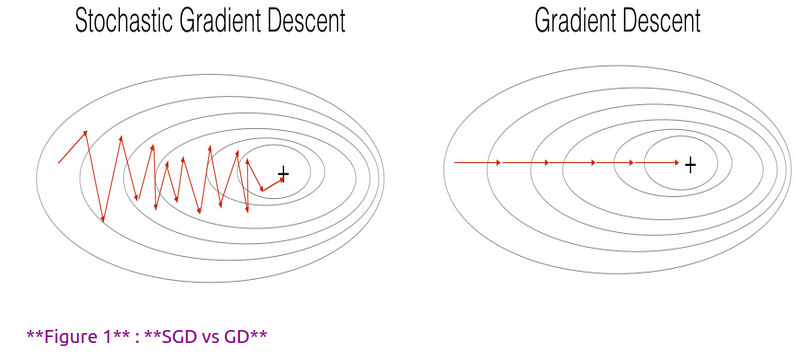


"+" denotes a minimum of the cost. SGD leads to many oscillations to reach convergence. But each step is a lot faster to compute for SGD than for GD, as it uses only one training example (vs. the whole batch for GD).

**Notes** Also implementing SGD requires 3  for-loops in total:

1. Over the number of iteration
2. Over the m training examples
3. OVer the layers (to update all parametersm from $$(W^{[1]}, b^{[1]}) to (W^{[L]}, b^{[L]})$$


In practice, you'll often get faster results if you do not use neither the whole training set, nor only one training example, to perform each update. Mini-batch gradient descent uses an intermediate number of examples for each step. With mini-batch gradient descent, you loop over the mini-batches instead of looping over individual training examples.

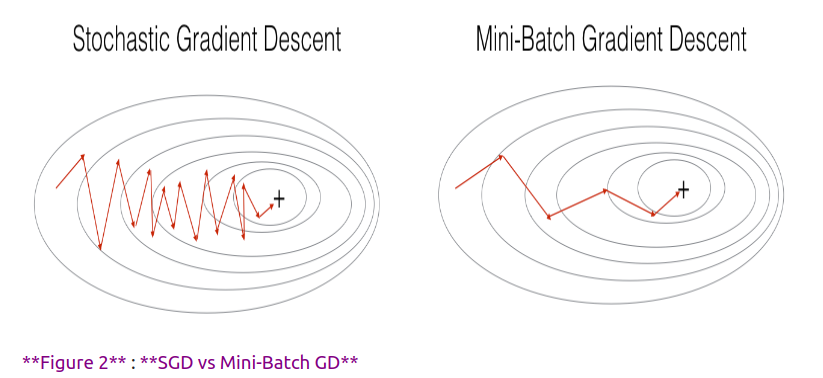

 "+" denotes a minimum of the cost. Using mini-batches in your optimization algorithm often leads to faster optimization. **What you should remember**: - The difference between gradient descent, mini-batch gradient descent and stochastic gradient descent is the number of examples you use to perform one update step. - You have to tune a learning rate hyperparameter $/alpha$ . - With a well-turned mini-batch size, usually it outperforms either gradient descent or stochastic gradient descent (particularly when the training set is large).

## MiniBatch Gradient Descent
Let's learn how to build mini-batches from the training set (X, Y).

There are  2 steps:

* **Shuffle**: Create a shuffled version of the training set (X, Y) as shown below. Each column of X and Y represents a training example. Note that the random shuffling is done synchronously between X and Y. Such that after the shuffling the
$$i^{th}$$ column of X is the example corresponding to the $$i^{th}$$ label in Y. THe shuffling step ensures that examples will be split randomly into different mini-batches

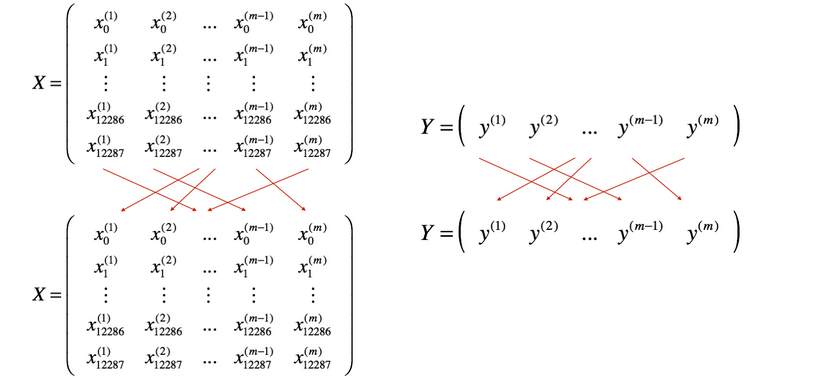

* **Partition**: Partition the shuffled (X, Y) into `mini-batches` of size `mini_batch_size (here 64)`. Note that the number of training examples is not always divisible by mini_batch_size. The last mini batch might be smaller, but you don't need to worry about this. When the final mini-batch is smaller than the full mini_batch_size, it will look like this:


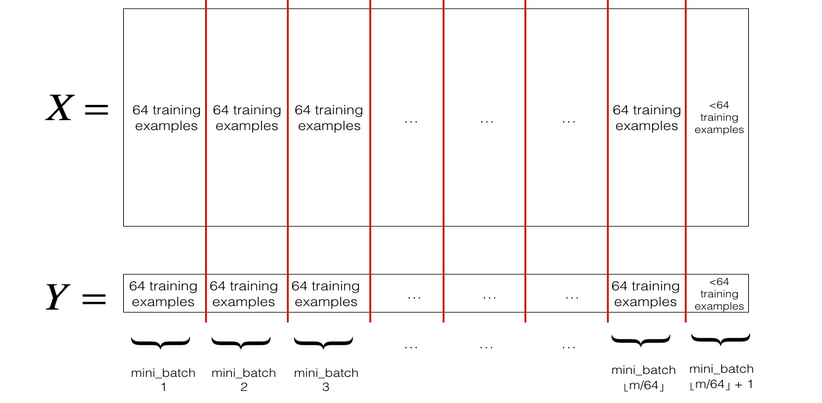

In [37]:
def random_mini_batches(X, Y, mini_batch_size = 64, seed = 0):
  """ Create a list of mini_batches from (X, Y)
  Arguments:
  X -- input data, of shape (input_size, number of examples)
  Y -- true "label" vector (1 for blue dot / 0 for red dot), of shape (1, number of examples)
  mini_batch_size -- size of the mini-batches, integer

  Returns:
  mini_batches --- list of synchronous (mini_batch_X, mini_batch_Y)
  """
  np.random.seed(seed)
  m = X.shape[1]
  mini_batches = []

  # Step 1: Shuffle (X, Y)
  permutation = list(np.random.permutation(m))
  shuffled_X = X[:, permutation]
  shuffled_Y = Y[:, permutation]

  # Step 2: Partition (shuffled_X, shuffled_Y)
  num_complete_minibatches = m // mini_batch_size

  for k in range(num_complete_minibatches):
      mini_batch_X = shuffled_X[:, k * mini_batch_size:(k + 1) * mini_batch_size]
      mini_batch_Y = shuffled_Y[:, k * mini_batch_size:(k + 1) * mini_batch_size]

      mini_batches.append((mini_batch_X, mini_batch_Y))

  # Step 3: Handle the end case
  if m % mini_batch_size != 0:
      mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size:]
      mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size:]
      mini_batches.append((mini_batch_X, mini_batch_Y))

  return mini_batches





In [38]:
X_asses , Y_asses , mini_batch_size = random_mini_batches_test_case()
mini_batches = random_mini_batches(X_asses, Y_asses, mini_batch_size)


print("Shape of 1st mini_batch_X: " + str(mini_batches[0][0].shape))
print("shape of 2nd mini_batch_X: " + str(mini_batches[1][0].shape))
print("shape of 3rd mini_batch_X: " + str(mini_batches[2][0].shape))
print("shape of 1st mini_batch_Y: " + str(mini_batches[0][0].shape))
print("shape of 1st mini_batch_Y: " + str(mini_batches[1][1].shape))
print("shape of 1st mini_batch_Y: " + str(mini_batches[2][1].shape))
print('mini batch sanity check:' + str(mini_batches[0][0][0][0:3]))

Shape of 1st mini_batch_X: (2, 2)
shape of 2nd mini_batch_X: (2, 2)
shape of 3rd mini_batch_X: (2, 1)
shape of 1st mini_batch_Y: (2, 2)
shape of 1st mini_batch_Y: (1, 2)
shape of 1st mini_batch_Y: (1, 1)
mini batch sanity check:[ 3. -1.]


**Summmary**  Shuffling and partitoning are the 2 steps required to build the mini-batches -Powers of 2 are often chosen to be th emini-batch size eg: 16, 32, 64 etc..

## Moementum
Because mini-batch gradient descent makes a parameter update after seeing just a subset of examples , the direction of the update has some variance, and so the path taken by mini-batch gradient descent will "oscillate" toward convergence. Using the momentum can reduce these oscillations.

Momentum takes into account the past gradients to smooth out the update . we'll stop the 'direction' of the previous gradients in the variabel v. Formally , this will bw the exponentially weighted average of the gradient on the previous steps. We can also think of the "velocity" of a ball rolling downhill, building up speed( and momentum) according to the direction of the gradient/slop of the hill

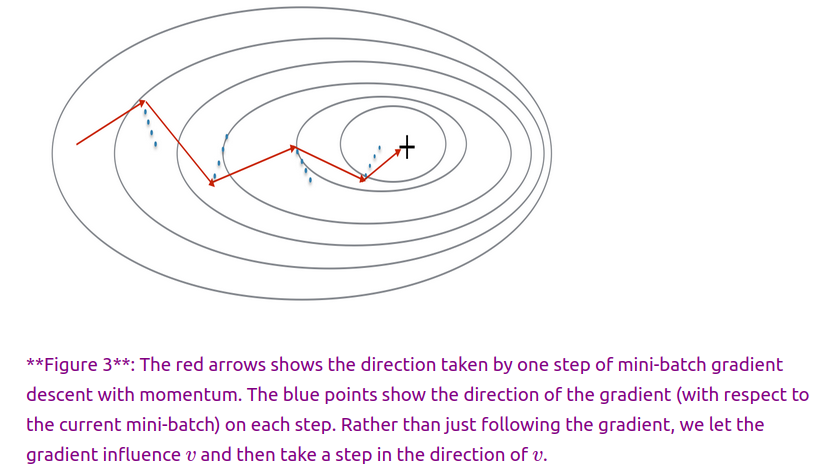


Now we initialize the velocity v, is a python dict: that needs to be initialized with arrays  of zeros. Its keys are the same as those in the `grads` dictionary, that is : for l = 1, ..., L:
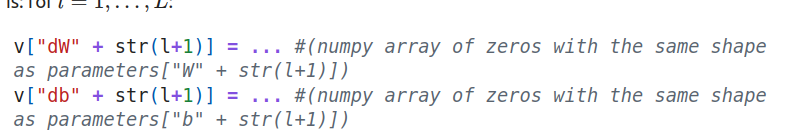

**Note** that the iterator I starts at 0 in the for loop while starting the first parameters are v["W1"] and ["db1"] (that's a "one" on the superscript). This is why we are shifting l to l+1 in the for loop.

In [39]:
def initialize_velocity(parameters):
  """
  Initializes the velocity as a python dictionary with:
              - keys: "dW1", "db1", ..., "dWL", "dbL"
              - values: numpy arrays of zeros of the same shape as the corresponding gradients/parameters.
  Arguments:
  parameters -- python dictionary containing your parameters.
                  parameters['W' + str(l)] = Wl
                  parameters['b' + str(l)] = bl

  Returns:
  v -- python dictionary containing the current velocity.
                  v['dW' + str(l)] = velocity of dWl
                  v['db' + str(l)] = velocity of dbl
  """

  L = len(parameters) // 2 # number of layers in  the neural networks
  v = {}

  for l in range(L):
    v["dW" + str(l + 1)] = np.zeros_like(parameters["W" + str(l+1)])
    v["db" + str(l + 1)] = np.zeros_like(parameters["b" + str(l+1)])

  return v





In [40]:
parameters = initialize_velocity_test_case()
v = initialize_velocity(parameters)
print("v[\"dW1\"] = " + str(v["dW1"]))
print("v[\"db1\"] = " + str(v["db1"]))
print("v[\"dW2\"] = " + str(v["dW2"]))
print("v[\"db2\"] = " + str(v["db2"]))

v["dW1"] = [[0. 0.]
 [0. 0.]]
v["db1"] = [[0.]
 [0.]]
v["dW2"] = [[0. 0.]]
v["db2"] = [[0.]]


Now we implement the parameters update with momentum. The momentum update rule is , for l = 1, .... L

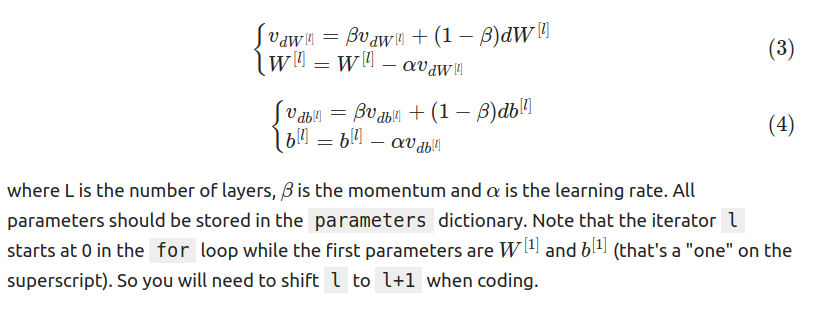


In [41]:
def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):
  """
  Update parameters using Momentum

  Arguments:
  parameters -- python dictionary containing your parameters:
                  parameters['W' + str(l)] = Wl
                  parameters['b' + str(l)] = bl
  grads -- python dictionary containing your gradients for each parameters:
                  grads['dW' + str(l)] = dWl
                  grads['db' + str(l)] = dbl
  v -- python dictionary containing the current velocity:
                  v['dW' + str(l)] = ...
                  v['db' + str(l)] = ...
  beta -- the momentum hyperparameter, scalar
  learning_rate -- the learning rate, scalar

  Returns:
  parameters -- python dictionary containing your updated parameters
  v -- python dictionary containing your updated velocities
  """
  L = len(parameters) // 2  # number of layers

  for l in range(L):
      # Compute velocities
      v["dW" + str(l + 1)] = beta * v["dW" + str(l + 1)] + \
                              (1 - beta) * grads["dW" + str(l + 1)]
      v["db" + str(l + 1)] = beta * v["db" + str(l + 1)] + \
                              (1 - beta) * grads["db" + str(l + 1)]

      # Update parameters
      parameters["W" + str(l + 1)] -= learning_rate * v["dW" + str(l + 1)]
      parameters["b" + str(l + 1)] -= learning_rate * v["db" + str(l + 1)]

  return parameters, v

In [42]:
parameters, grads,v = update_parameters_with_momentum_test_case()

parameters, v = update_parameters_with_momentum(parameters, grads, v, beta= 0.9, learning_rate = 0.01)
print("W1  = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2  = " + str(parameters["W2"]))
print("b2  = " + str(parameters["b2"]))
print("v[\"dW1\"] = " + str(v["dW1"]))
print("v[\"db1\"] = " + str(v["db1"]))
print("v[\"dW2\"] = " + str(v["dW2"]))
print("v[\"db2\"] = " + str(v["db2"]))


W1  = [[ 1.62466778 -0.61137236]
 [-0.52930552 -1.07186873]]
b1 = [[ 0.86528899]
 [-2.3011945 ]]
W2  = [[ 1.74476461 -0.76121458]]
b2  = [[0.31906091]]
v["dW1"] = [[-0.03224172 -0.03840543]
 [ 0.11337694 -0.10998913]]
v["db1"] = [[ 0.01186383]
 [-0.03442043]]
v["dW2"] = [[0.00471471 0.00076826]]
v["db2"] = [[-0.00218062]]


**Note** The velocity is initialized with zeros. SO that algorithm will take a few interations to "build up" velocity and start to take bigger steps

* If $\beta$ = 0, then it just becomes standard gradient descent without mementum.
How do we chose $\beta$?

* TThe larger the momentum $\beta$ is, the smoother the update because the more we take the past gradients into account. But if $\beta$ is too big, it could also smooth out the updates too much.
* Common values for $\beta$ ranges from .8 to 0.999.If we don't feel inclined to tune this. $\beta$ = 0.9 is often reasonable default.

* Tuning the optimal  $\beta$ for your model might need trying several values to see what works best in term of reducing the value of the cost function J .

**Summary** : - Momentum takes past gradients into account to smooth out the steps of gradient descent. It can be applied with batch gradient descent, mini-batch gradient descent or stochastic gradient descent. - You have to tune a momentum hyperparameter  $\beta$ and a learning rate $\alpha$.

## Adam
Adam is one of the most effective optimization algorithms for learing neural networks. It combines ideas from RMSProp and Momentum.

**How does it work**
1. It calculates an exponentially weighted average of past gradients, and stores it in variables v (before bias correction) and $$v^{corrected}$$ (with bias correction)
2. It calculates an exponentially weighted average of the squares of the past gradients, and stores it in variables s (before bias correction) and $$s^{corrected}$$ (with bias correction)
3. It updates parameters in a direction based on combining the information from "1" and "2".


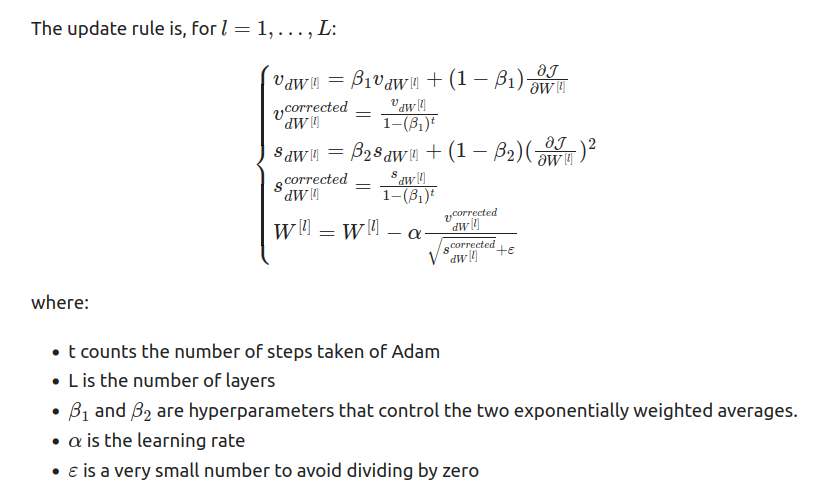

As usual, we will store all `parameters` in the parameters dictionary

In [43]:
def initialize_adam(parameters):
  """
  Initializes v and s as  two Python dictionaries with:
      - keys : "dW1", "db1", ..., "dWL", "dbL"
      - values: numpy arrays of zeros of the same shape as the corresponding gradients/parameters.
  Arguments:
  parameters -- python dictionary containing your parameters.
                parameters["W" + str(l)] = Wl
                parameters["b" + str(l)] = bl
  Returns:
  v -- python dictionary that will contain the exponentially weighted average of the gradient.

                v["dW" + str(l)] = ...
                v["db" + str(l)] = ...

  s -- python dictionary that will contain the exponentially weighted average of the squared gradient.
                 s["dW" + str(l)] = ...
                  s["db" + str(l)] = ...
  """
  L = len(parameters) // 2
  v = {}
  s = {}

  # Initialize v, s. Input: "parameters". Outputs: "v, s".

  for l in range(L):
    v["dW" + str(l + 1)] = np.zeros_like(parameters["W" + str(l + 1)])
    v["db" + str(l + 1)] = np.zeros_like(parameters["b" + str(l + 1)])

    s["dW" + str(l+1)] = np.zeros_like(parameters["W" + str(l + 1)])
    s["db" + str(l+1)] = np.zeros_like(parameters["b" + str(l + 1)])
  return v, s





In [44]:
parameters = initialize_adam_test_case()

v, s = initialize_adam(parameters)

print("v[\"dW1\"] = " + str(v["dW1"]))
print("v[\"db1\"] = " + str(v["db1"]))
print("v[\"dW2\"] = " + str(v["dW2"]))
print("v[\"db2\"] = " + str(v["db2"]))
print("s[\"dW1\"] = " + str(s["dW1"]))
print("s[\"db1\"] = " + str(s["db1"]))
print("s[\"dW2\"] = " + str(s["dW2"]))
print("s[\"db2\"] = " + str(s["db2"]))


v["dW1"] = [[0. 0.]
 [0. 0.]]
v["db1"] = [[0.]
 [0.]]
v["dW2"] = [[0. 0.]]
v["db2"] = [[0.]]
s["dW1"] = [[0. 0.]
 [0. 0.]]
s["db1"] = [[0.]
 [0.]]
s["dW2"] = [[0. 0.]]
s["db2"] = [[0.]]


Now we implement parameter update with Adam. The general rule for update is l = 1, ...L


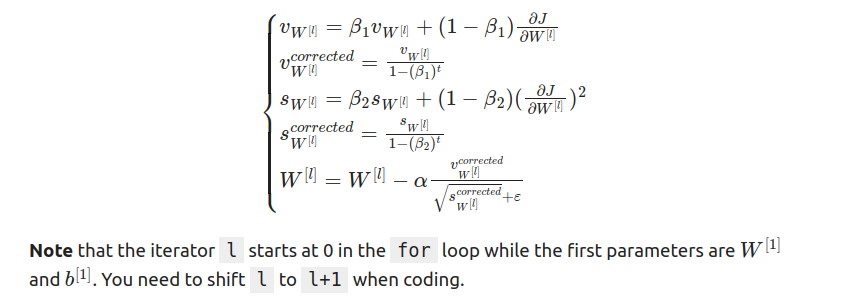

In [45]:
# GRADED _FUNCTION : update_parameters_with_adam

def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate=0.01,
                                beta1=0.9, beta2=0.999, epsilon=1e-8):
  """
  Update parameters with Adam

  Arguments:
  parameters: -- python dict: containing the parameters:
      parameters["W" + str(l)] = Wl
      parameters["b" + str(l)] = bl
  grads -- python dict: containing the gradients for each parameters:
      grads['dW' + str(l)] = dWl
      grads['db] + str(l)] = dbl
  v -- Adam variable, moving average of the first gradient, python dictionary
  s -- Adam variable, moving average of the squared gradient, python dictionary
  beta1 -- Exponential decay hyperparameter for the first moment estimates
  beta2 = Exponential decay hyperparameter for the second moment estimates
  epsilon -- hyperparameter preventing division by zero in Adam updates

  Returns:
  parameters -- python dict: containing the updated parameters
  v -- Adam variable, moving average of the gradient, python dictionary
  s -- Adam varialbe , moving average of the squared gradient, python dictionary
  """
  L = len(parameters) // 2
  v_corrected = {}
  s_corrected = {}

  # Perform Adam update for all parameters
  for l in range(L):
  # Moving average of the gradients. Inputs: "v, grads, beta1". Output: "v".
    v["dW" + str(l + 1)] = beta1 * v["dW" + str(l + 1)] + (1 - beta1) * grads['dW' + str(l + 1)]
    v["db" + str(l + 1)] = beta1 * v["db" + str(l + 1)] + (1 - beta1) * grads['db' + str(l + 1)]

    # compute the bias-corrected first moment estimate,Inputs : "v, beta1, t", Outputs: "v_corrected"
    v_corrected["dW" + str(l + 1)] = v["dW" + str(l + 1)] / (1 - np.power(beta1, t))
    v_corrected["db" + str(l + 1)] = v["db" + str(l + 1)] / (1 - np.power(beta1, t))

    # Moving average of the squared gradients. Inputs: "s, grads, beta2". Output: "s".
    s["dW" + str(l + 1)] = beta2 * s["dW" + str(l + 1)] + (1 - beta2) * np.power(grads['dW' + str(l + 1)], 2)
    s["db" + str(l +1 )] = beta2 * s["db" + str(l + 1)] + (1 - beta2) * np.power(grads['db' + str(l + 1)], 2)

    # Compute the bias corrected second moment estimate
    s["dW" + str(l + 1)] = beta2 * s["dW" + str(l + 1)] + (1 - beta2) * np.power(grads['dW' + str(l + 1)], 2)
    s["db" + str(l + 1)] = beta2 * s["db" + str(l + 1)] + (1 - beta2) * np.power(grads['db' + str(l + 1)], 2)

    # Compute bias-corrected second raw moment estimate. Inputs: "s, beta2, t". Output: "s_corrected".
    s_corrected["dW" + str(l + 1)] = s["dW" + str(l + 1)] / (1 - np.power(beta2, t))
    s_corrected["db" + str(l + 1)] = s["db" + str(l + 1)] / (1 - np.power(beta2, t))

    # Update the parameters : "parameters, learning_rate, v_corrected, s_corrected, epsilon". Output:"parameters"
    parameters["W" + str(l + 1)] = parameters["W" + str(l + 1)] - learning_rate * v_corrected["dW" + str(l +1 )] / np.sqrt(s["dW" + str(l + 1)] + epsilon)
    parameters["b" + str(l + 1)] = parameters["b" + str(l + 1)] - learning_rate * v_corrected["db" + str(l + 1)] / np.sqrt(s["db" + str(l + 1)] + epsilon)


  return parameters, v, s



In [46]:
parameters, grads , v, s, t = update_parameters_with_adam_test_case()
parameters, v, s = update_parameters_with_adam(parameters, grads, v, s, t=2)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
print("v[\"dW1\"] = " + str(v["dW1"]))
print("v[\"db1\"] = " + str(v["db1"]))
print("v[\"dW2\"] = " + str(v["dW2"]))
print("v[\"db2\"] = " + str(v["db2"]))
print("s[\"dW1\"] = " + str(s["dW1"]))
print("s[\"db1\"] = " + str(s["db1"]))
print("s[\"dW2\"] = " + str(s["dW2"]))
print("s[\"db2\"] = " + str(s["db2"]))

W1 = [[ 1.74205975 -0.49404118]
 [-0.64588874 -0.95525164]]
b1 = [[ 0.74771132]
 [-2.18382396]]
W2 = [[ 1.62722678 -0.87423177]]
b2 = [[0.43614195]]
v["dW1"] = [[-0.03224172 -0.03840543]
 [ 0.11337694 -0.10998913]]
v["db1"] = [[ 0.01186383]
 [-0.03442043]]
v["dW2"] = [[0.00471471 0.00076826]]
v["db2"] = [[-0.00218062]]
s["dW1"] = [[0.0002078  0.00029485]
 [0.00256958 0.00241831]]
s["db1"] = [[2.81360316e-05]
 [2.36834696e-04]]
s["dW2"] = [[4.44346957e-06 1.17985970e-07]]
s["db2"] = [[9.50541719e-07]]




We now have three working optimization algorithms (mini-batch gradient descent, Momentum, Adam). Let's implement a model with each of these optimizers and observe the difference.


## Model with different optimization algorithms

Lets use the following "moons" dataset to test the different optimization methods. (The dataset is named "moons" because the data from each of the two classes looks a bit like a crescent-shaped moon.)



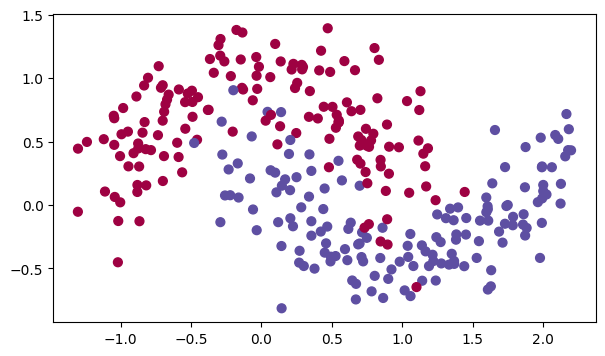

In [47]:
train_X, train_Y = load_dataset()

We have already implemented a 3-layer neural network. You will train it with:

* Mini-batch **Gradient Descent** : It will call the function:
  * `update_parameters_with_gd()`
* Mini-batch **Momentum** : it call the functions:
   * `initialize_velocity()` and `update_parameters_with_momentum()`  
* Mini-batch **Adam** : It will call the functions
  *  `initialize_adam()` and `update_parameters_with_adam()`


In [53]:
def model(X, Y, layers_dims, optimizer, learning_rate=0.0007, mini_batch_size=64, beta=0.9,
          beta1=0.9, beta2=0.999, epsilon=1e-8, num_epochs=10000, print_cost=True):
    """
    2-layer neural network model which can be run in different optimizer modes.
    #  3-layer neural network model which can be run in different optimizer modes.

    Arguemnts:
    X -- input data, of shape (2, number of examples)
    Y -- true "label" vector (1 for blue dot / 0 for red dot), of shape (1, number of examples)
    layers_dims -- python list, containing the size of each layer
    learning_rate -- the learning rate , scalar.
    mini_batch_size -- the size of a mini batch
    beta --  Momentum hyperparameter
    beta1 -- Exponential decay hyperparameter for the past gradients estimates
    beta2 -- Exponential decay hyperparameter for the past squared gradients estimates
    epsilon -- hyperparameter preventing division by zero in Adam updates
    num_epochs -- number of epochs of the optimization loop
    print_cost --- True to print the cost every 1000 epochs

    Returns
    parameters -- python dictionary containing the updated parameters

    """

    costs = []
    t = 0
    seed = 10

    # Initialize parameters
    parameters = initialize_parameters(layers_dims)

    # Initialize optimizer
    if optimizer == "gd":
        pass
    elif optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)

    # Optimization loop
    for i in range(num_epochs):

        seed += 1
        minibatches = random_mini_batches(X, Y, mini_batch_size, seed)

        for minibatch in minibatches:

            minibatch_X, minibatch_Y = minibatch

            # Forward propagation
            AL, caches = forward_propagation(minibatch_X, parameters)

            # Compute cost
            cost = compute_cost(AL, minibatch_Y)

            # Backward propagation (FIXED)
            grads = backward_propagation(AL, minibatch_Y, caches)

            # Update parameters
            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t += 1
                parameters, v, s = update_parameters_with_adam(
                    parameters, grads, v, s, t,
                    learning_rate, beta1, beta2, epsilon
                )

        # Record and print cost
        if print_cost and i % 1000 == 0:
            print(f"Cost after epoch {i}: {cost:.6f}")
        if print_cost and i % 100 == 0:
            costs.append(cost)

    # Plot cost AFTER training
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('epochs (per 100)')
    plt.title("Learning rate = " + str(learning_rate))
    plt.show()

    return parameters


We will now run this 3 layer neural network with each of the 3 optimization methods.

## Mini Batch Gradient Descent
Let see how the model do with the mini-batch gradient descent




Cost after epoch 0: 0.693149
Cost after epoch 1000: 0.693153
Cost after epoch 2000: 0.693149
Cost after epoch 3000: 0.693106
Cost after epoch 4000: 0.693139
Cost after epoch 5000: 0.693146
Cost after epoch 6000: 0.693105
Cost after epoch 7000: 0.693141
Cost after epoch 8000: 0.693154
Cost after epoch 9000: 0.693142


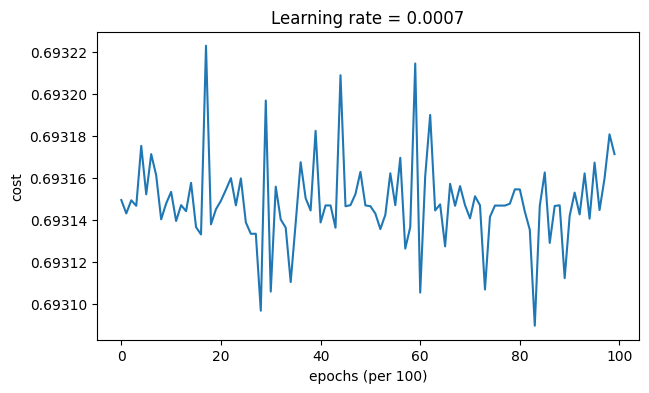

Accuracy: 0.5


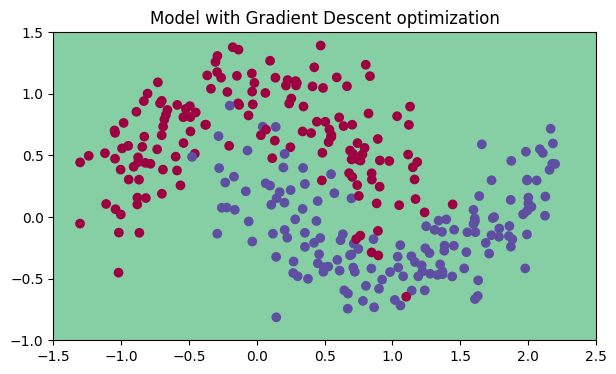

In [55]:
#  train 3-layer model
layers_dims = [train_X.shape[0], 5, 2, 1]
parameters = model(train_X, train_Y, layers_dims, optimizer="gd")

# Predict
predictions = predict(train_X, train_Y, parameters)

# Plot decision boundary
plt.title("Model with Gradient Descent optimization")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1, 1.5])
plot_decision_boundary(
    lambda x: predict_dec(parameters, x),
    train_X,
    train_Y
)


## MiniBatch With Adam Mode


Cost after epoch 0: 0.694852
Cost after epoch 1000: 0.374539
Cost after epoch 2000: 0.386972
Cost after epoch 3000: 0.345148
Cost after epoch 4000: 0.333320
Cost after epoch 5000: 0.270391
Cost after epoch 6000: 0.285675
Cost after epoch 7000: 0.166398
Cost after epoch 8000: 0.286720
Cost after epoch 9000: 0.449264


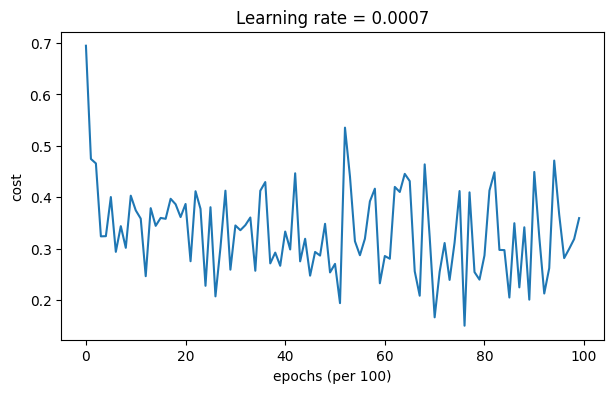

Accuracy: 0.8566666666666667


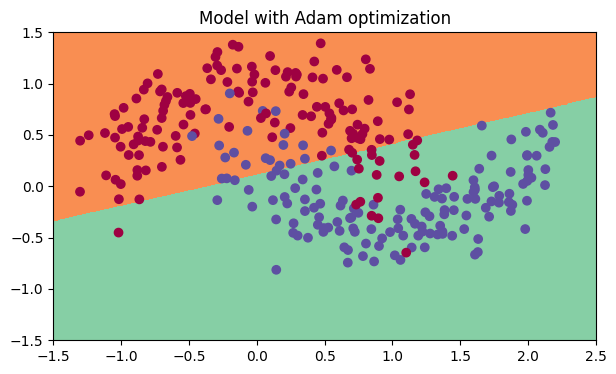

In [58]:
layers_dims = [train_X.shape[0], 5, 2, 1]
parameters = model(train_X, train_Y, layers_dims, optimizer="adam")

# Predict
predictions = predict(train_X, train_Y, parameters)

plt.title("Model with Adam optimization")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1.5, 1.5])
plot_decision_boundary(
    lambda x: predict_dec(parameters, x),
    train_X,
    train_Y
)

## Summary
Momentum usually helps, but given the small learning rate and the simplistic dataset, its impact is almost negligeable. Also, the huge oscillations you see in the cost come from the fact that some minibatches are more difficult thans others for the optimization algorithm.

Adam on the other hand, clearly outperforms mini-batch gradient descent and Momentum. If you run the model for more epochs on this simple dataset, all three methods will lead to very good results. However, you've seen that Adam converges a lot faster.

Some advantages of Adam include:
* Relatively low memory requirements (though higher than the gradient descent and gradient descent with momenum)
* Usually works better even with little tuning of hyperparameters (except $$\alpha$$)